In [47]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

pi = jnp.pi

In [48]:
def u_exact_new(x):
    return -jnp.cos(x) + (3/8) * jnp.sin(x) - (1/8) * jnp.sin(3*x)

In [49]:
def init_mlp(layers, key):
    params = []
    keys = jax.random.split(key, len(layers)-1)

    for k, (m, n) in zip(keys, zip(layers[:-1], layers[1:])):
        W = jax.random.normal(k, (m, n)) * jnp.sqrt(2/m)
        b = jnp.zeros(n)
        params.append((W, b))

    return params


def mlp(params, x):
    for W, b in params[:-1]:
        x = jnp.tanh(x @ W + b)
    W, b = params[-1]
    return x @ W + b


def u_model(params, x):
    return mlp(params, x.reshape(-1,1)).squeeze()

In [50]:
def dudx(params, x):
    return jax.grad(lambda z: u_model(params, z))(x)


def d2udx2(params, x):
    return jax.grad(lambda z: dudx(params, z))(x)

def residual(params, x):
    return d2udx2(params, x) + u_model(params, x) - jnp.sin(3*x)

In [51]:
def loss_fn(params, xs):
    res = jax.vmap(lambda x: residual(params, x))(xs)
    interior = jnp.mean(res**2)

    # boundary conditions
    bc = (
        (u_model(params, jnp.array(0.0)) + dudx(params, jnp.array(0.0)) + 1)**2 +
        (dudx(params, jnp.pi/2) - 1)**2
    )

    return interior + bc

In [52]:
def loss_fn(params, xs):
    res = jax.vmap(lambda x: residual(params, x))(xs)
    interior = jnp.mean(res**2)

    # boundary conditions
    bc = (
        (u_model(params, jnp.array(0.0)) + dudx(params, jnp.array(0.0)) + 1)**2 +
        (dudx(params, jnp.pi/2) - 1)**2
    )

    return interior + bc

| iteration= 0   |   loss= 53.962524   |   l1_error= 0.52715576
| iteration= 500   |   loss= 0.09231625   |   l1_error= 0.14979613
| iteration= 1000   |   loss= 0.04473843   |   l1_error= 0.063935995
| iteration= 1500   |   loss= 0.026601203   |   l1_error= 0.04261537
| iteration= 2000   |   loss= 0.0148077635   |   l1_error= 0.027047953
| iteration= 2500   |   loss= 0.0060502323   |   l1_error= 0.01316153
| iteration= 3000   |   loss= 0.0014332094   |   l1_error= 0.0038298592
| iteration= 3500   |   loss= 0.00055456697   |   l1_error= 0.0015916118


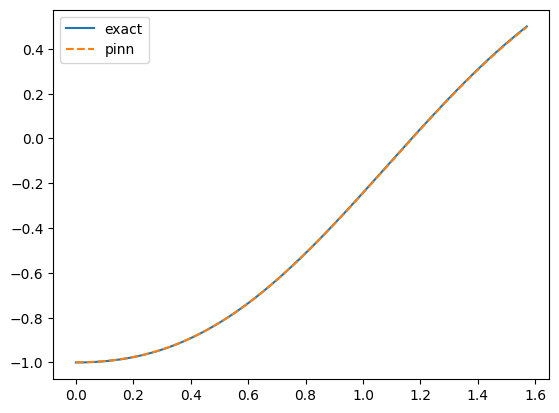

In [53]:
key = jax.random.PRNGKey(0)
params = init_mlp([1, 32, 32, 1], key)

xs = jnp.linspace(0, jnp.pi/2, 100)
x_plot = jnp.linspace(0, jnp.pi/2, 200)
u_exact_plot = u_exact_new(x_plot)

opt = optax.adam(1e-3)
opt_state = opt.init(params)

@jax.jit
def step(params, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, xs)
    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

for i in range(4000):
    params, opt_state, loss = step(params, opt_state)
    if i % 500 == 0:
        u_pred_plot = jax.vmap(lambda x: u_model(params, x))(x_plot)
        l1_error = jnp.mean(jnp.abs(u_pred_plot - u_exact_plot))
        print( "| iteration=",i,  "  |   loss=", loss, "  |   l1_error=", l1_error)

u_pred = jax.vmap(lambda x: u_model(params, x))(x_plot)
u_exact = u_exact_new(x_plot)

plt.plot(x_plot, u_exact, label="exact")
plt.plot(x_plot, u_pred, "--", label="pinn")
plt.legend()
plt.show()

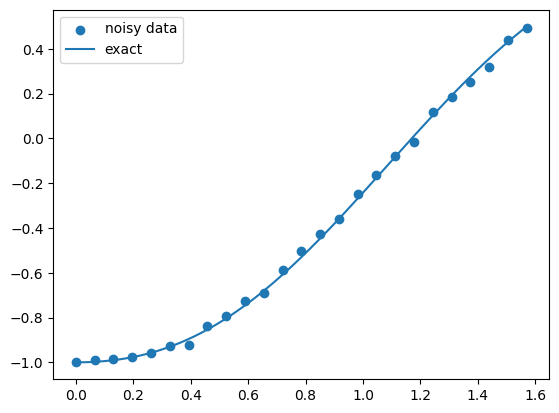

In [54]:
key = jax.random.PRNGKey(42)

n_obs = 25
x_obs = jnp.linspace(0, jnp.pi/2, n_obs)

u_exact_obs = u_exact_new(x_obs)

noise_level = 0.02
noise = noise_level * jax.random.normal(key, x_obs.shape)

u_obs = u_exact_obs + noise

plt.scatter(x_obs, u_obs, label="noisy data")
plt.plot(x_plot, u_exact_new(x_plot), label="exact")
plt.legend()
plt.show()

In [55]:
def residual_inv(params, alpha, x):
    return d2udx2(params, x) + u_model(params, x) - jnp.sin(alpha*x)

In [56]:
def loss_inv(theta, xs, x_obs, u_obs):
    params, alpha = theta

    res = jax.vmap(lambda x: residual_inv(params, alpha, x))(xs)
    physics_loss = jnp.mean(res**2)

    # boundary conditions for inverse PINN
    bc_loss = (
        (u_model(params, jnp.array(0.0)) + dudx(params, jnp.array(0.0)) + 1)**2 +
        (dudx(params, jnp.pi/2) - 1)**2
    )

    pred_obs = jax.vmap(lambda x: u_model(params, x))(x_obs)
    data_loss = jnp.mean((pred_obs - u_obs)**2)

    return physics_loss + bc_loss + data_loss

In [57]:
alpha = jnp.array(2.0) # Initial guess for alpha, true value is 3
theta = (params, alpha)

opt_inv = optax.adam(1e-3)
opt_state_inv = opt_inv.init(theta)


| iteration= 0 |  loss= 0.4890435 |  alpha= 2.001
| iteration= 1000 |  loss= 0.011823461 |  alpha= 2.613714
| iteration= 2000 |  loss= 0.0009274751 |  alpha= 2.9114528
| iteration= 3000 |  loss= 0.00067149237 |  alpha= 2.9855845
| iteration= 4000 |  loss= 0.0003366265 |  alpha= 2.993056
| iteration= 5000 |  loss= 0.0006073688 |  alpha= 2.9922898
Learned alpha: 2.991696
True alpha: 3.0


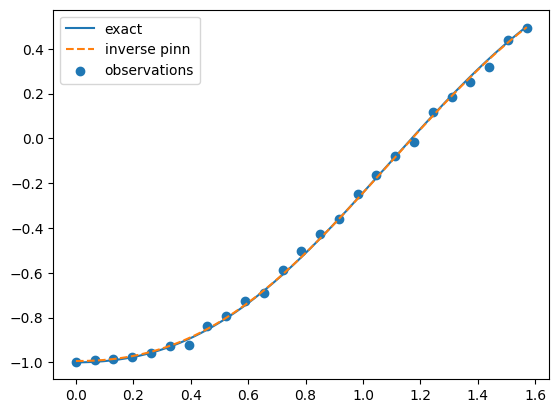

In [58]:
@jax.jit
def step_inv(theta, opt_state_inv, xs, x_obs, u_obs):
    loss, grads = jax.value_and_grad(loss_inv)(theta, xs, x_obs, u_obs)
    updates, opt_state_inv = opt_inv.update(grads, opt_state_inv, theta)
    theta = optax.apply_updates(theta, updates)
    return theta, opt_state_inv, loss

for i in range(6000):
    theta, opt_state_inv, loss = step_inv(theta, opt_state_inv, xs, x_obs, u_obs)
    if i % 1000 == 0:
        print( "| iteration=", i, "|  loss=", loss, "|  alpha=", theta[1])

params_learned_inv, alpha_learned = theta

print("Learned alpha:", alpha_learned)
print("True alpha:", 3.0) # True value of alpha for data generation

u_pred_inv = jax.vmap(lambda x: u_model(params_learned_inv, x))(x_plot)
u_exact_plot = u_exact_new(x_plot) # Re-using u_exact_new for comparison

plt.plot(x_plot, u_exact_plot, label="exact")
plt.plot(x_plot, u_pred_inv, "--", label="inverse pinn")
plt.scatter(x_obs, u_obs, label="observations")
plt.legend()
plt.show()